
# 🧭 **Análisis de Componentes Principales (PCA) y Comparación con y sin Estandarización**
---

### 🧠 *Introducción*

El **Análisis de Componentes Principales (PCA)** es una técnica estadística que reduce la dimensionalidad de los datos encontrando **nuevas direcciones (componentes principales)** que explican la mayor parte de la varianza de los datos.

📊 **Objetivo:**  
Representar los datos en menos dimensiones sin perder demasiada información.

💡 **Importancia de la estandarización:**  
PCA es **sensible a la escala de las variables**, por lo que las variables con unidades grandes pueden dominar el análisis si no se escalan previamente.  
En este notebook compararemos el efecto de aplicar PCA **con y sin estandarización**.



### 📦 *Dataset de ejemplo*
Usaremos el dataset **Iris** del paquete `seaborn`. Este dataset tiene 4 variables numéricas (longitud y ancho de sépalos y pétalos) y una variable categórica con la especie de flor.


In [ ]:

import seaborn as sns
import pandas as pd

# Cargar dataset
iris = sns.load_dataset('iris')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



### 🚫 *PCA sin estandarización*
Primero aplicaremos PCA directamente sobre los datos sin escalar.  
Esto puede generar resultados sesgados porque las variables con valores más grandes (por ejemplo, longitud del pétalo) influirán más en el resultado.


In [ ]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
from sklearn.decomposition import PCA

# Variables numéricas
X = iris.drop(columns=['species'])

# Aplicar PCA sin escalar
pca_no_scaling = PCA(n_components=2)
X_pca_no_scaling = pca_no_scaling.fit_transform(X)

# Crear DataFrame con resultados
iris_no_scaling = pd.DataFrame(X_pca_no_scaling, columns=['PC1', 'PC2'])
iris_no_scaling['species'] = iris['species']
iris_no_scaling.head()


,PC1,PC2,species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa
3,-2.745343,-0.318299,setosa
4,-2.728717,0.326755,setosa



### 📉 *Visualización del PCA sin estandarizar*
Observemos cómo los clusters de especies aparecen distorsionados debido a las diferencias en la escala de las variables originales.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


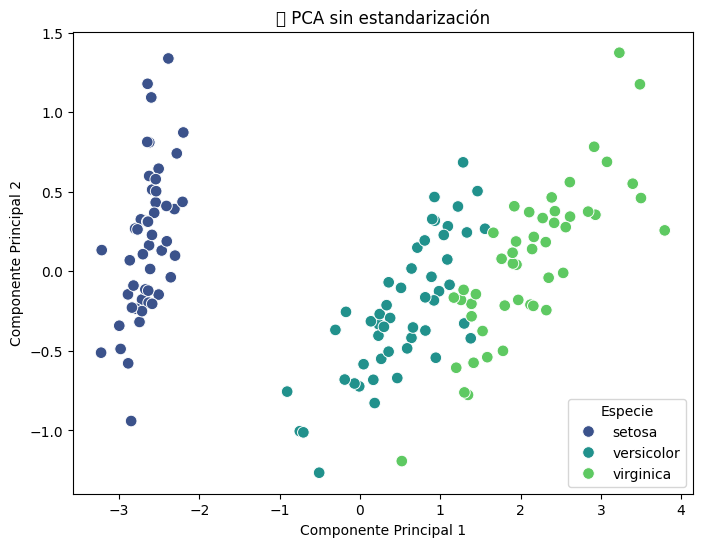

Varianza explicada (sin escalar): [0.92461872 0.05306648]


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=iris_no_scaling, x='PC1', y='PC2', hue='species', palette='viridis', s=70)
plt.title("🚫 PCA sin estandarización")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title='Especie')
plt.show()

print("Varianza explicada (sin escalar):", pca_no_scaling.explained_variance_ratio_)


In [ ]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      


### ⚙️ *PCA con estandarización*
Ahora aplicamos el mismo análisis, pero esta vez **escalamos las variables** para que todas tengan media 0 y desviación estándar 1.  
Esto garantiza que todas las variables contribuyan de forma equilibrada al PCA.


In [ ]:
X_pca_scaled

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA escalado
pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

# Crear DataFrame con resultados
iris_scaled = pd.DataFrame(X_pca_scaled, columns=['PC1', 'PC2'])
iris_scaled['species'] = iris['species']
iris_scaled.head()


,PC1,PC2,species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa



### 🎨 *Visualización del PCA con estandarización*
Aquí los clusters deberían verse más definidos y equilibrados entre especies.  
Esto se debe a que la escala ya no influye en la dirección de los componentes principales.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


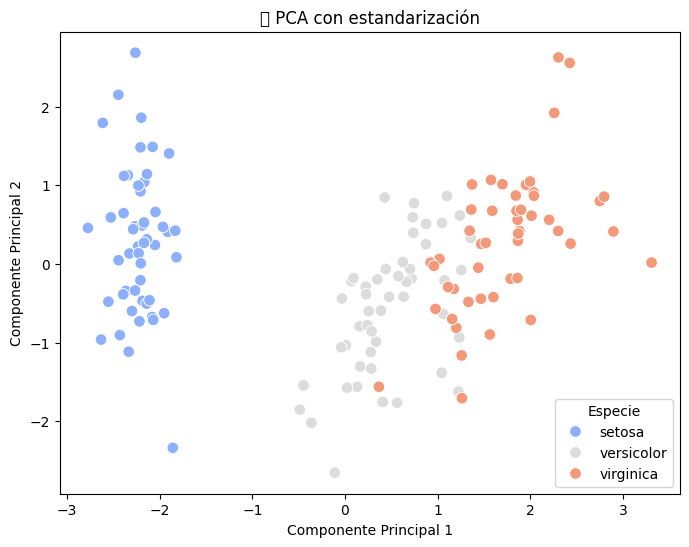

Varianza explicada (con estandarización): [0.72962445 0.22850762]


In [ ]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=iris_scaled, x='PC1', y='PC2', hue='species', palette='coolwarm', s=70)
plt.title("✅ PCA con estandarización")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title='Especie')
plt.show()

print("Varianza explicada (con estandarización):", pca_scaled.explained_variance_ratio_)



### 🔍 *Comparación visual directa*
Graficamos ambas proyecciones una al lado de la otra para observar las diferencias de forma más clara.


/tmp/ipython-input-1072922724.py:15: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1072922724.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


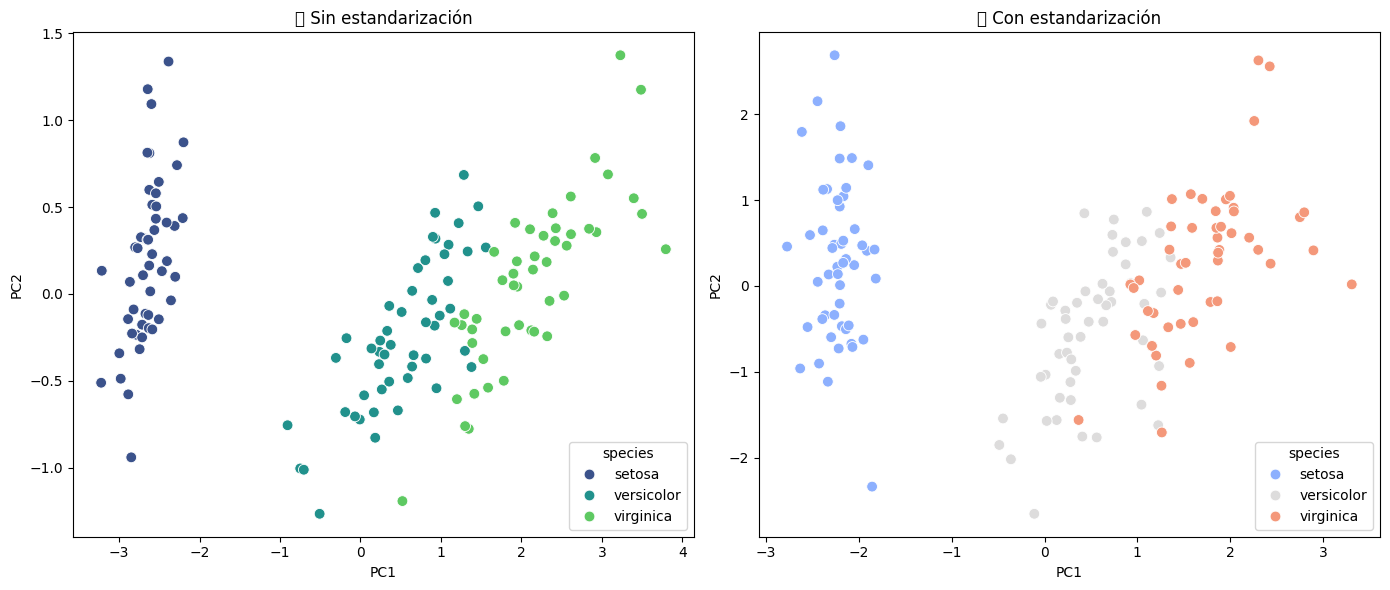

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Sin escalar
sns.scatterplot(data=iris_no_scaling, x='PC1', y='PC2', hue='species', palette='viridis', s=60, ax=axes[0])
axes[0].set_title("🚫 Sin estandarización")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Con estandarización
sns.scatterplot(data=iris_scaled, x='PC1', y='PC2', hue='species', palette='coolwarm', s=60, ax=axes[1])
axes[1].set_title("✅ Con estandarización")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()



### 🧭 *Conclusiones*
- 🚫 Sin escalar los datos, el PCA da **más peso a las variables con valores numéricamente grandes**, distorsionando el resultado.  
- ✅ Con estandarización, todas las variables contribuyen por igual, y los clusters se visualizan de forma **más clara y equilibrada**.  
- 🌿 En el caso del dataset Iris, el PCA con escalado captura mejor la separación entre especies, lo que demuestra la **importancia del preprocesamiento** en análisis multivariados.

**✨ En resumen:** *Estandarizar antes de aplicar PCA es una buena práctica casi siempre.*


In [ ]:
iris['index'] = iris.index
iris_scaled['index'] = iris_scaled.index
iris_no_scaling['index'] = iris_no_scaling.index

In [ ]:
iris_merge = iris.merge(iris_scaled, on = 'index').merge(iris_no_scaling, on = 'index')
iris_merge.rename(columns = {'species_x': 'species_real',
                             'species_y': 'species_escaled',
                             'species': 'species_no_scaling'}, inplace = True)

In [ ]:
iris_merge['comp_scaled'] = iris_merge['species_real'] == iris_merge['species_escaled']
iris_merge['comp_no_scaling'] = iris_merge['species_real'] == iris_merge['species_no_scaling']

In [ ]:
iris_merge['comp_scaled'].value_counts()

,count
comp_scaled,
True,150


In [ ]:
iris_merge['comp_no_scaling'].value_counts()

,count
comp_no_scaling,
True,150
